Author: MJ

In [10]:
import sys
print(sys.version)

3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


In [ ]:
# pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.


In [12]:
# %pip install scipy matplotlib seaborn scikit-learn --quiet

In [13]:
import pickle
# Tuple from the pickle file
with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, vectorizer1, vectorizer2 = pickle.load(f)

print(f"X1 shape: {X1.shape}, X2 shape: {X2.shape}, y shape: {y.shape}")

X1 shape: (48, 629), X2 shape: (48, 1000), y shape: (48,)


Loading preprocessed data...
Dataset: 48 samples, 33 unique classes
SVM: 1-gram=0.00000, 2-gram=0.02083
KNN_k3: 1-gram=0.02083, 2-gram=0.02083
KNN_k5: 1-gram=0.00000, 2-gram=0.00000
DecisionTree: 1-gram=0.04167, 2-gram=0.08333


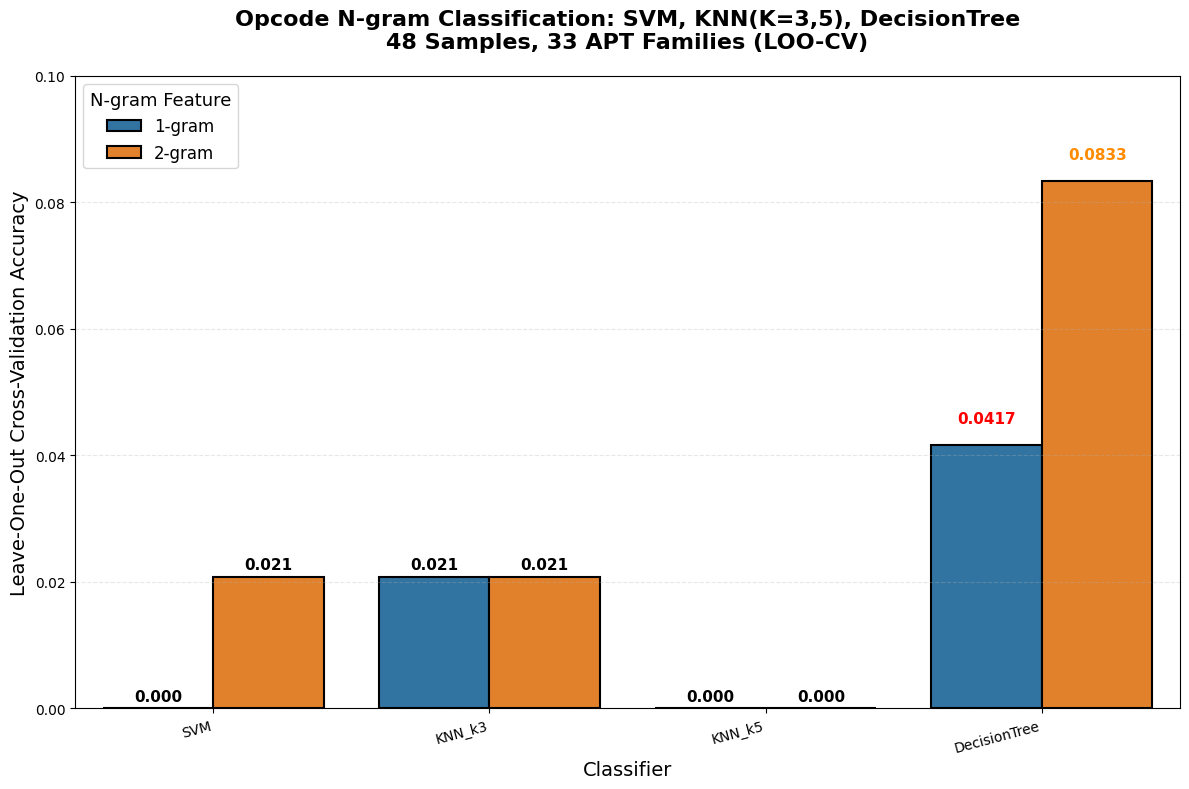

Main comparison graph saved


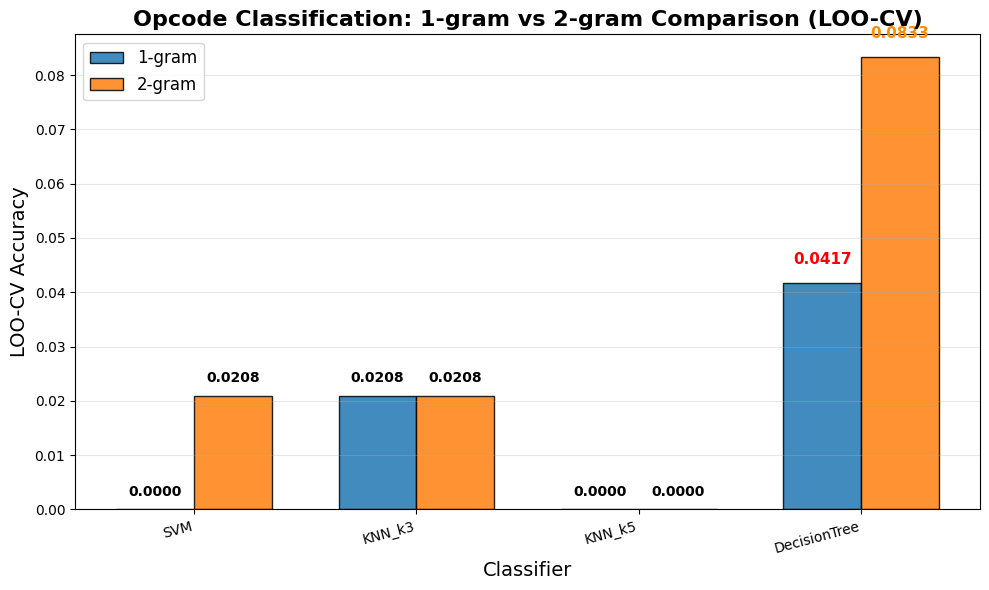

Summary grouped bar chart saved

Performance Ranking (1-gram LOOCV):
1. DecisionTree: 0.04167
2. KNN_k3: 0.02083
3. SVM: 0.00000
4. KNN_k5: 0.00000


In [25]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os

# Create output directories
os.makedirs('ml_data', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Load preprocessed opcode TF-IDF data
print("Loading preprocessed data...")
with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, _, _ = pickle.load(f)

print(f"Dataset: {X1.shape[0]} samples, {len(np.unique(y))} unique classes")

loo = LeaveOneOut()

# Define classifiers for comparison
models = {
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN_k3': KNeighborsClassifier(n_neighbors=3),
    'KNN_k5': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

# Run Leave-One-Out Cross-Validation
results = {}
for name, model in models.items():
    # 1-gram TF-IDF features
    acc1 = cross_val_score(model, X1, y, cv=loo, scoring='accuracy').mean()
    # 2-gram TF-IDF features  
    acc2 = cross_val_score(model, X2, y, cv=loo, scoring='accuracy').mean()
    results[name] = {'1gram': acc1, '2gram': acc2}
    print(f"{name}: 1-gram={acc1:.5f}, 2-gram={acc2:.5f}")

# Save detailed results
df_results = pd.DataFrame(results).T.round(5)
df_results.to_csv('ml_data/all_classifiers_k3_k5_results.csv')

# Prepare data for visualization
results_long = pd.DataFrame({
    'Classifier': list(results.keys())*2,
    'Ngram': ['1-gram']*4 + ['2-gram']*4,
    'Accuracy': [results[k]['1gram'] for k in results.keys()] + 
                [results[k]['2gram'] for k in results.keys()]
})

# Plot 1: Seaborn barplot with DecisionTree fix
plt.figure(figsize=(12, 8))
bars = sns.barplot(data=results_long, x='Classifier', y='Accuracy', hue='Ngram',
                   palette=['#1f77b4', '#ff7f0e'], edgecolor='black', linewidth=1.5)

# Rotate and align x-axis labels
plt.xticks(rotation=15, ha='right')
plt.title('Opcode N-gram Classification: SVM, KNN(K=3,5), DecisionTree\n48 Samples, 33 APT Families (LOO-CV)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Leave-One-Out Cross-Validation Accuracy', fontsize=14)
plt.xlabel('Classifier', fontsize=14)
plt.ylim(0, max(results_long['Accuracy']) * 1.2)
plt.legend(title='N-gram Feature', fontsize=12, title_fontsize=13)
plt.grid(axis='y', alpha=0.3, linestyle='--')

# FIXED: DecisionTree value labels with higher precision and better positioning
max_acc = max(results_long['Accuracy'])
for i, container in enumerate(bars.containers):
    for j, (bar, acc) in enumerate(zip(container, results_long['Accuracy'][i*4:(i+1)*4])):
        height = bar.get_height()
        # Special handling for DecisionTree (index 3)
        if results_long.iloc[i*4+j]['Classifier'] == 'DecisionTree':
            label = f'{acc:.4f}'  # 4 decimals for DecisionTree
            offset = 0.003
            color = 'red' if i == 0 else 'darkorange'  # 1-gram red, 2-gram orange
        else:
            label = f'{acc:.3f}'
            offset = max_acc * 0.008
            color = 'black'
        
        plt.text(bar.get_x() + bar.get_width()/2., height + offset,
                label, ha='center', va='bottom', fontweight='bold', 
                fontsize=11, color=color)

plt.tight_layout()
plt.savefig('results/all_classifiers_k3_k5_comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Main comparison graph saved")

# Plot 2: Manual grouped bar chart - DecisionTree fix
plt.figure(figsize=(10, 6))
x_pos = np.arange(len(models))
width = 0.35

# Grouped bars
plt.bar(x_pos - width/2, [results[k]['1gram'] for k in models.keys()], width, 
        label='1-gram', color="#1f77b4", edgecolor='black', alpha=0.85)
plt.bar(x_pos + width/2, [results[k]['2gram'] for k in models.keys()], width, 
        label='2-gram', color="#ff7f0e", edgecolor='black', alpha=0.85)

# FIXED: DecisionTree labels with special formatting
for i, name in enumerate(models.keys()):
    # 1-gram label
    if name == 'DecisionTree':
        plt.text(i - width/2, results[name]['1gram'] + 0.003, f'{results[name]["1gram"]:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=11, color='red')
    else:
        plt.text(i - width/2, results[name]['1gram'] + 0.002, f'{results[name]["1gram"]:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    
    # 2-gram label  
    if name == 'DecisionTree':
        plt.text(i + width/2, results[name]['2gram'] + 0.003, f'{results[name]["2gram"]:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=11, color='darkorange')
    else:
        plt.text(i + width/2, results[name]['2gram'] + 0.002, f'{results[name]["2gram"]:.4f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.xlabel('Classifier', fontsize=14)
plt.ylabel('LOO-CV Accuracy', fontsize=14)
plt.title('Opcode Classification: 1-gram vs 2-gram Comparison (LOO-CV)', fontsize=16, fontweight='bold')
plt.xticks(x_pos, models.keys(), rotation=15, ha='right')
plt.legend(fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('results/classifiers_k3_k5_summary.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("Summary grouped bar chart saved")

# Print final performance ranking
print("\nPerformance Ranking (1-gram LOOCV):")
ranking_1g = sorted(results.items(), key=lambda x: x[1]['1gram'], reverse=True)
for i, (name, vals) in enumerate(ranking_1g, 1):
    print(f"{i}. {name}: {vals['1gram']:.5f}")


In [26]:
df_results


,1gram,2gram
SVM,0.00000,0.02083
KNN_k3,0.02083,0.02083
KNN_k5,0.00000,0.00000
DecisionTree,0.04167,0.08333


4. 48 Dataset vs Augumented Data

Loading augmented data...
Dataset: 378 samples, 33 classes
Class distribution: Counter({np.str_('APT29'): 13, np.str_('APT1'): 12, np.str_('APT28'): 12, np.str_('APT33'): 12, np.str_('APT39'): 12, np.str_('APT41'): 12, np.str_('Cobalt'): 12, np.str_('FIN5'): 12, np.str_('FIN7'): 12, np.str_('Moafee'): 12, np.str_('Patchwork'): 12, np.str_('Sidewinder'): 12, np.str_('TEMPVeles'): 12, np.str_('Turla'): 12, np.str_('APT16'): 11, np.str_('APT17'): 11, np.str_('APT19'): 11, np.str_('APT3'): 11, np.str_('Axiom'): 11, np.str_('BRONZEBUTLER'): 11, np.str_('BlueMockingbird'): 11, np.str_('Chimera'): 11, np.str_('DeepPanda'): 11, np.str_('Dragonfly'): 11, np.str_('Elderwood'): 11, np.str_('Evilnum'): 11, np.str_('Gallium'): 11, np.str_('Gamaredon'): 11, np.str_('HAFNIUM'): 11, np.str_('Ke3chang'): 11, np.str_('MenuPass'): 11, np.str_('SandwormTeam'): 11, np.str_('admin338'): 11})
APT classes: ['APT1' 'APT16' 'APT17' 'APT19' 'APT28' 'APT29' 'APT3' 'APT33' 'APT39'
 'APT41' 'Axiom' 'BRONZEBUTLER' '

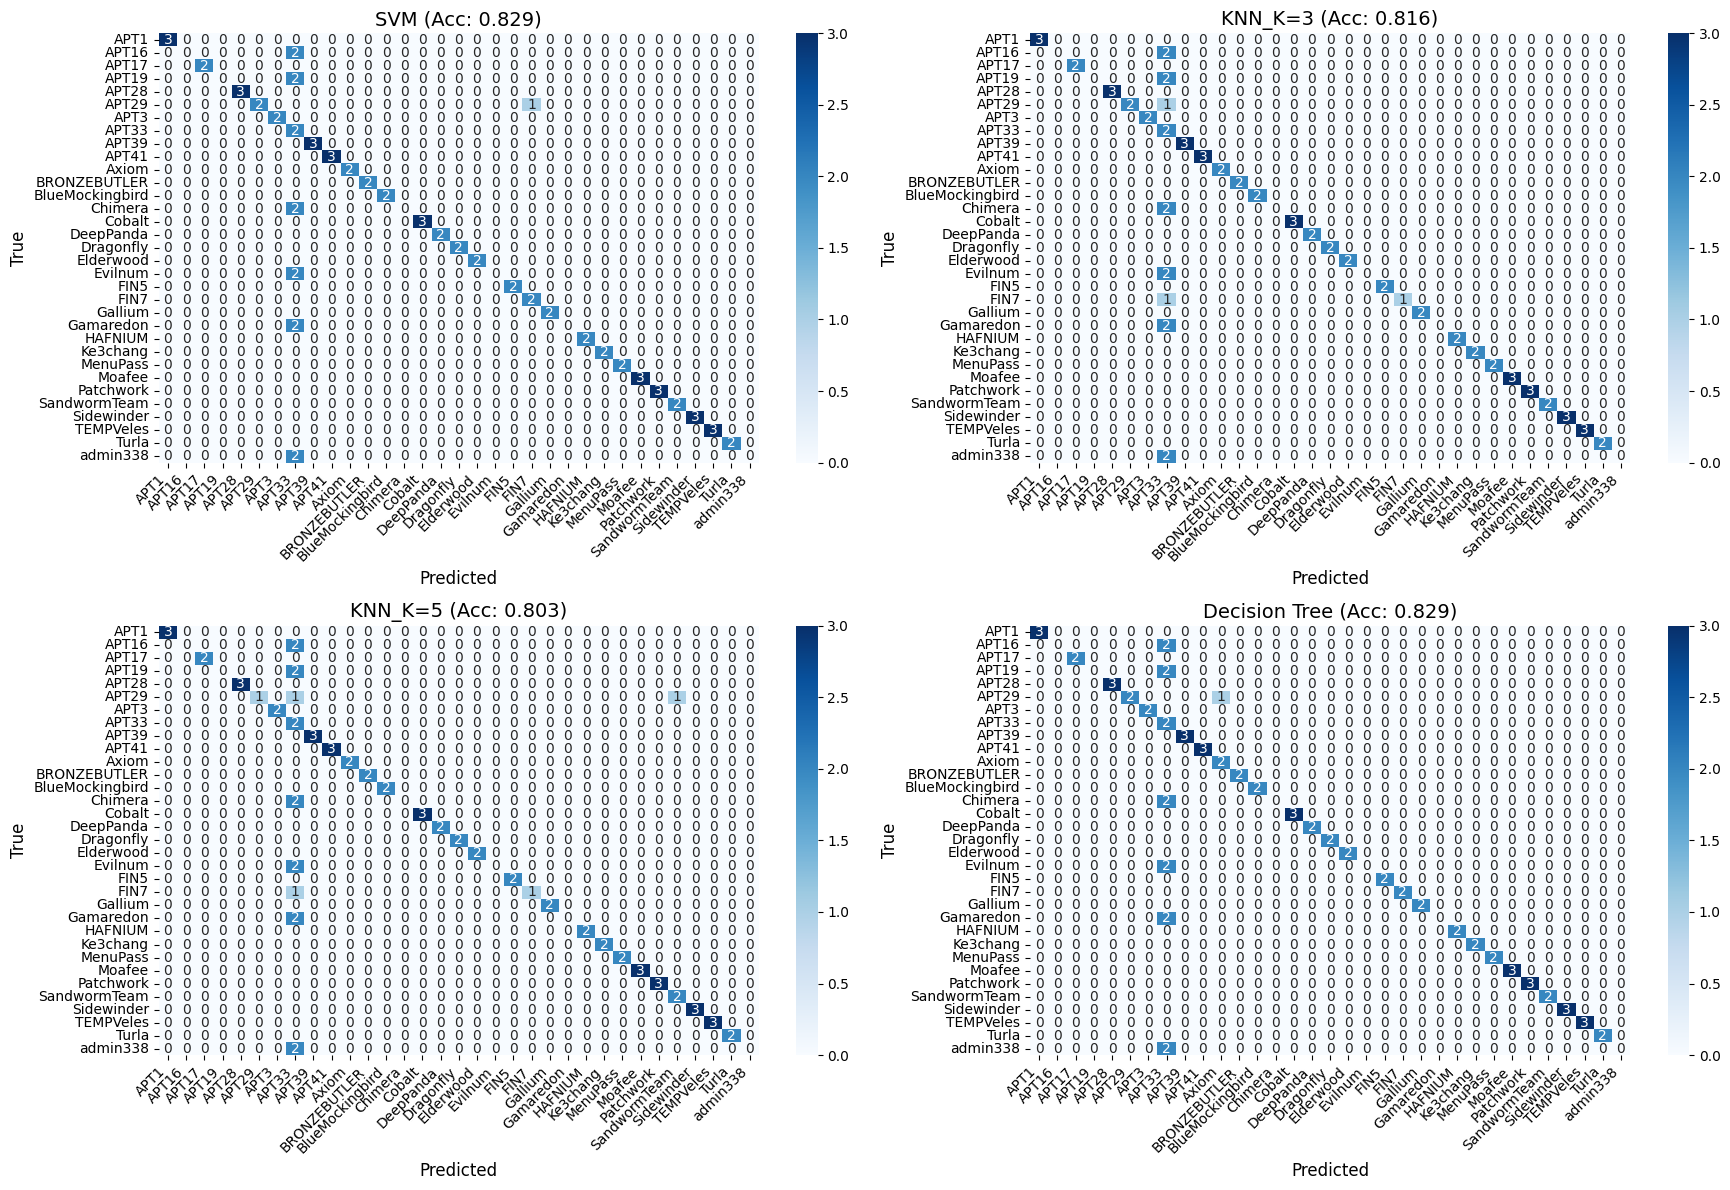


FINAL RESULTS SUMMARY
Model           Accuracy  
--------------------------------------------------
SVM             0.829     
Decision Tree   0.829     
KNN_K=3         0.816     
KNN_K=5         0.803     


In [28]:
import pickle
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse


# Load augmented data
print("Loading augmented data...")
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1, X2, y, scaler1, scaler2 = pickle.load(f)

print(f"Dataset: {len(y)} samples, {len(np.unique(y))} classes")
print("Class distribution:", Counter(y))

# APT group name list (string labels as they are)
apt_classes = np.unique(y)
print("APT classes:", apt_classes)

# Prepare feature sets (1-gram + 2-gram combined)
if sparse.issparse(X1) and sparse.issparse(X2):
    X_combined = sparse.hstack([X1, X2])
else:
    X_combined = np.hstack([X1, X2])

print(f"Combined features: {X_combined.shape}")

# Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {len(y_train)} samples, Test: {len(y_test)} samples")

# Models to evaluate
models = {
    'SVM': SVC(kernel='linear', C=1.0, random_state=42),
    'KNN_K=3': KNeighborsClassifier(n_neighbors=3),
    'KNN_K=5': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42)
}

# Train and evaluate each model
results = {}
plt.figure(figsize=(18, 12))  # Larger figure size for better label visibility

for i, (name, model) in enumerate(models.items(), 1):
    print(f"\n--- Training {name} ---")
    
    # Train model on training data
    model.fit(X_train, y_train)
    
    # Predict on test data
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    
    print(f"Accuracy: {accuracy:.3f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=apt_classes))
    
    # Plot confusion matrix with APT group names on both axes
    plt.subplot(2, 2, i)
    cm = confusion_matrix(y_test, y_pred, labels=apt_classes)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=apt_classes,
        yticklabels=apt_classes
    )
    
    plt.title(f'{name} (Acc: {accuracy:.3f})', fontsize=14)
    plt.ylabel('True', fontsize=12)
    plt.xlabel('Predicted', fontsize=12)
    
    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45, ha='right', fontsize=10)
    # Keep y-axis labels vertical but readable
    plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('results/classification_results.png', dpi=300, bbox_inches='tight')
plt.show()

# Print final results summary table
print("\n" + "="*50)
print("FINAL RESULTS SUMMARY")
print("="*50)
print(f"{'Model':<15} {'Accuracy':<10}")
print("-"*50)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{name:<15} {acc:<10.3f}")


Various Train/Test Split Ratios

Loading augmented data...
Dataset: 378 samples, 33 classes
Class distribution: Counter({np.str_('APT29'): 13, np.str_('APT1'): 12, np.str_('APT28'): 12, np.str_('APT33'): 12, np.str_('APT39'): 12, np.str_('APT41'): 12, np.str_('Cobalt'): 12, np.str_('FIN5'): 12, np.str_('FIN7'): 12, np.str_('Moafee'): 12, np.str_('Patchwork'): 12, np.str_('Sidewinder'): 12, np.str_('TEMPVeles'): 12, np.str_('Turla'): 12, np.str_('APT16'): 11, np.str_('APT17'): 11, np.str_('APT19'): 11, np.str_('APT3'): 11, np.str_('Axiom'): 11, np.str_('BRONZEBUTLER'): 11, np.str_('BlueMockingbird'): 11, np.str_('Chimera'): 11, np.str_('DeepPanda'): 11, np.str_('Dragonfly'): 11, np.str_('Elderwood'): 11, np.str_('Evilnum'): 11, np.str_('Gallium'): 11, np.str_('Gamaredon'): 11, np.str_('HAFNIUM'): 11, np.str_('Ke3chang'): 11, np.str_('MenuPass'): 11, np.str_('SandwormTeam'): 11, np.str_('admin338'): 11})
Combined features: (378, 1629)

SPLIT RATIO: 60/40
Train: 226, Test: 152
SVM         : 0.980
KNN_K=3     : 0.941
KNN_

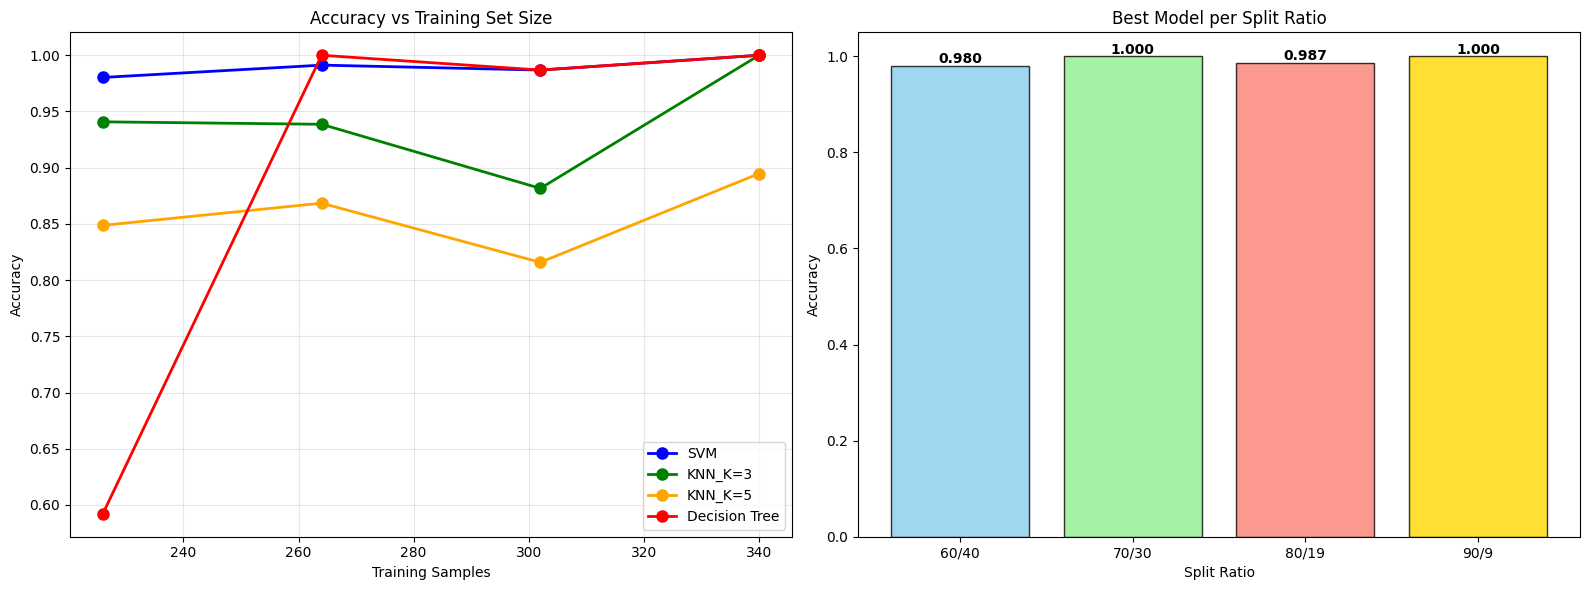


Results saved:
- 'split_ratio_comparison.png' (visualizations)
- 'split_ratio_results.csv' (detailed results)
- 'split_ratio_pivot_table.csv' (pivot summary)


In [ ]:
import pickle
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
import pandas as pd

# Load augmented data
print("Loading augmented data...")
with open('ml_data/manual_augmented_data_sparse.pkl', 'rb') as f:
    X1, X2, y, scaler1, scaler2 = pickle.load(f)

print(f"Dataset: {len(y)} samples, {len(np.unique(y))} classes")
print("Class distribution:", Counter(y))

# Prepare feature sets (1-gram + 2-gram combined)
if sparse.issparse(X1) and sparse.issparse(X2):
    X_combined = sparse.hstack([X1, X2])
else:
    X_combined = np.hstack([X1, X2])

print(f"Combined features: {X_combined.shape}")

# Split ratios to test
split_ratios = [0.6, 0.7, 0.8, 0.9]  # train_size
models = {
    'SVM': SVC(kernel='linear', C=1.0, random_state=42),
    'KNN_K=3': KNeighborsClassifier(n_neighbors=3),
    'KNN_K=5': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(max_depth=20, random_state=42)
}

# Results storage
all_results = []

# Test each split ratio
for train_size in split_ratios:
    print(f"\n{'='*60}")
    print(f"SPLIT RATIO: {int(train_size*100)}/{int((1-train_size)*100)}")
    print(f"{'='*60}")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X_combined, y, train_size=train_size, random_state=42, stratify=y
    )
    
    print(f"Train: {len(y_train)}, Test: {len(y_test)}")
    
    ratio_results = {}
    
    # Test each model
    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        ratio_results[name] = accuracy
        
        print(f"{name:12}: {accuracy:.3f}")
        
        # Store for comparison
        all_results.append({
            'Train/Test': f"{int(train_size*100)}/{int((1-train_size)*100)}",
            'Model': name,
            'Accuracy': accuracy,
            'Train_Samples': len(y_train),
            'Test_Samples': len(y_test)
        })
    
    print("-" * 60)

# Create comparison DataFrame
df_results = pd.DataFrame(all_results)

# Summary table
print("\n" + "="*80)
print("SPLIT RATIO COMPARISON SUMMARY")
print("="*80)
pivot_table = df_results.pivot_table(
    values='Accuracy', 
    index='Train/Test', 
    columns='Model', 
    aggfunc='mean'
).round(3)
print(pivot_table)

# Visualization - Fixed and optimized
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Line plot: Accuracy vs Training Samples
colors = ['blue', 'green', 'orange', 'red']
for i, model_name in enumerate(models.keys()):
    model_data = df_results[df_results['Model'] == model_name]
    ax1.plot(model_data['Train_Samples'], model_data['Accuracy'], 
             marker='o', label=model_name, linewidth=2, color=colors[i], markersize=8)
ax1.set_xlabel('Training Samples')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy vs Training Set Size')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Bar plot: Best model per split
best_per_split = df_results.loc[df_results.groupby('Train/Test')['Accuracy'].idxmax()]
x_pos = range(len(best_per_split))
colors_bar = ['skyblue', 'lightgreen', 'salmon', 'gold']
ax2.bar(x_pos, best_per_split['Accuracy'], 
        color=colors_bar, alpha=0.8, edgecolor='black')
ax2.set_xlabel('Split Ratio')
ax2.set_ylabel('Accuracy')
ax2.set_title('Best Model per Split Ratio')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(best_per_split['Train/Test'])
for i, acc in enumerate(best_per_split['Accuracy']):
    ax2.text(i, acc + 0.005, f'{acc:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('results/split_ratio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nResults saved:")
print("- 'split_ratio_comparison.png' (visualizations)")
print("- 'split_ratio_results.csv' (detailed results)")
print("- 'split_ratio_pivot_table.csv' (pivot summary)")


Loading preprocessed data...
Dataset: 48 samples, 33 unique classes

Running Leave-One-Out Cross-Validation with comprehensive metrics...

--- Evaluating SVM ---
SVM:
  1-gram - Acc: 0.000, Prec: 0.000, Rec: 0.000, F1: 0.000
  2-gram - Acc: 0.021, Prec: 0.021, Rec: 0.021, F1: 0.021

--- Evaluating KNN_k3 ---
KNN_k3:
  1-gram - Acc: 0.062, Prec: 0.062, Rec: 0.062, F1: 0.062
  2-gram - Acc: 0.062, Prec: 0.062, Rec: 0.062, F1: 0.062

--- Evaluating KNN_k5 ---
KNN_k5:
  1-gram - Acc: 0.021, Prec: 0.021, Rec: 0.021, F1: 0.021
  2-gram - Acc: 0.042, Prec: 0.042, Rec: 0.042, F1: 0.042

--- Evaluating DecisionTree ---
DecisionTree:
  1-gram - Acc: 0.104, Prec: 0.104, Rec: 0.104, F1: 0.104
  2-gram - Acc: 0.042, Prec: 0.042, Rec: 0.042, F1: 0.042

Detailed metrics saved to 'comprehensive_metrics_results.csv'

Accuracy Summary:
          SVM  KNN_k3  KNN_k5  DecisionTree
1-gram  0.000   0.062   0.021         0.104
2-gram  0.021   0.062   0.042         0.042


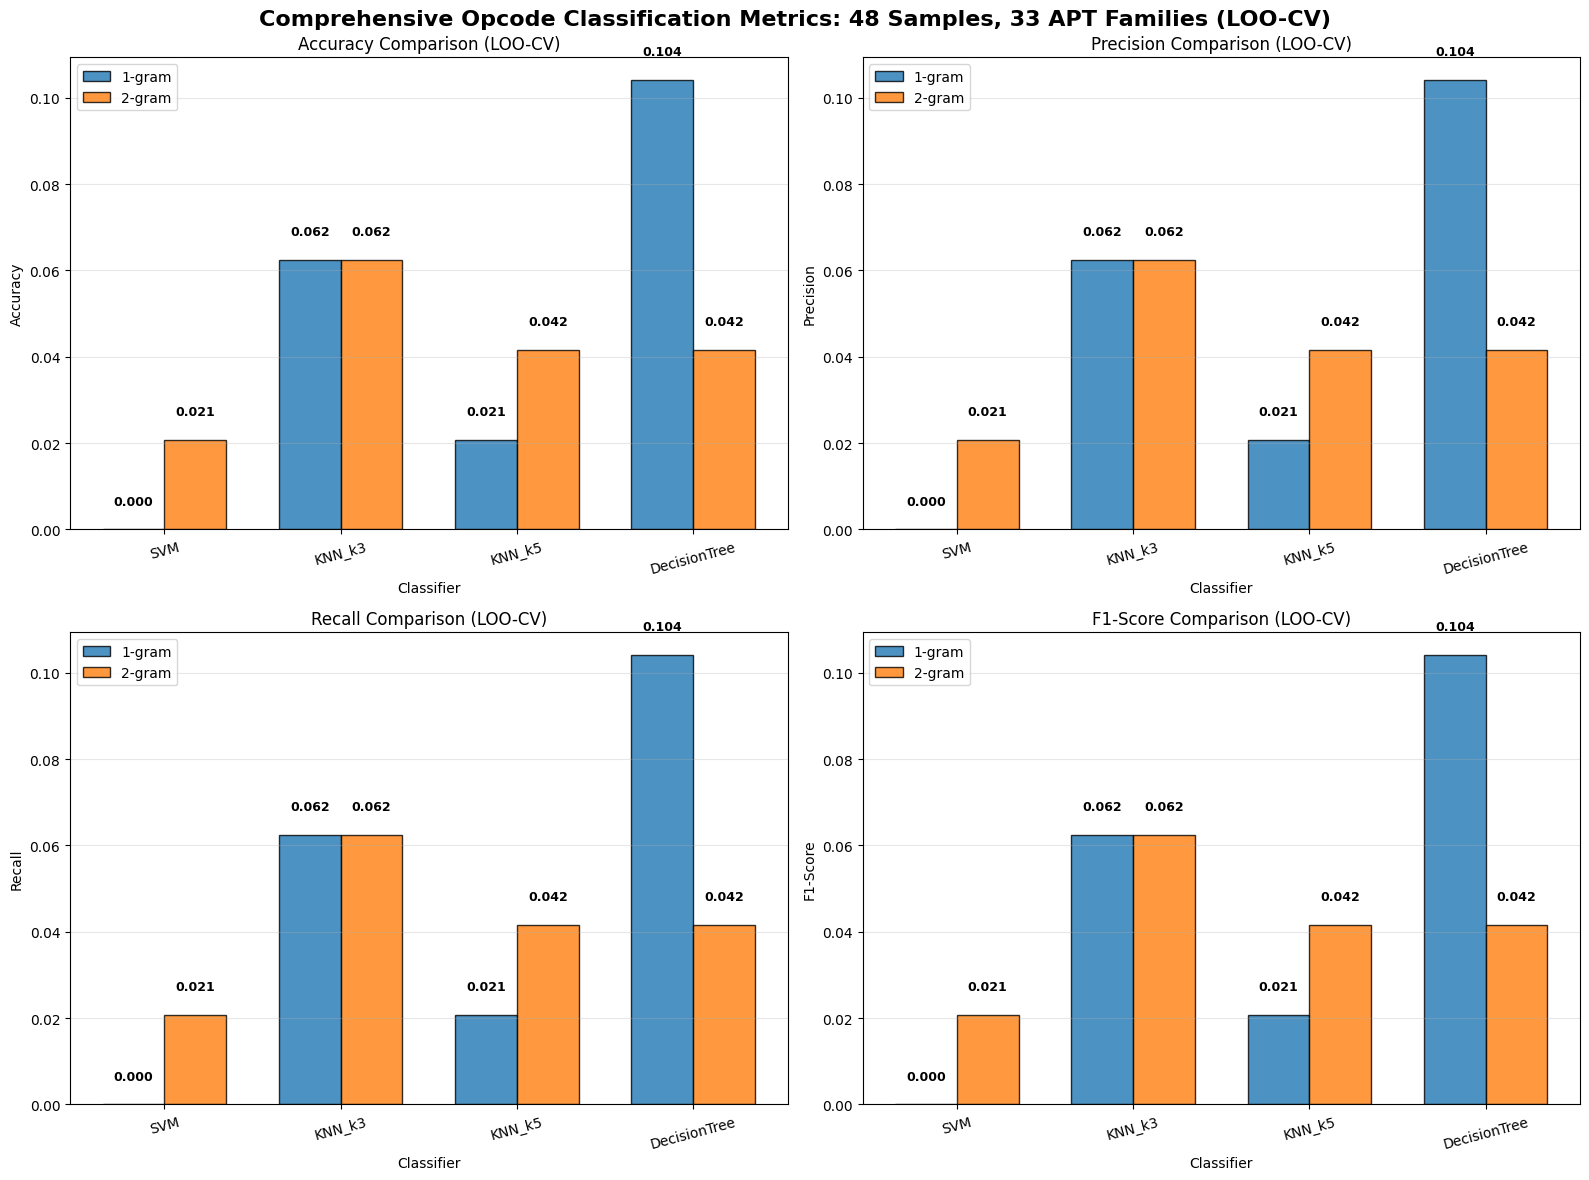


Generating confusion matrix for best model...
Best model: KNN_k3 (2-gram)


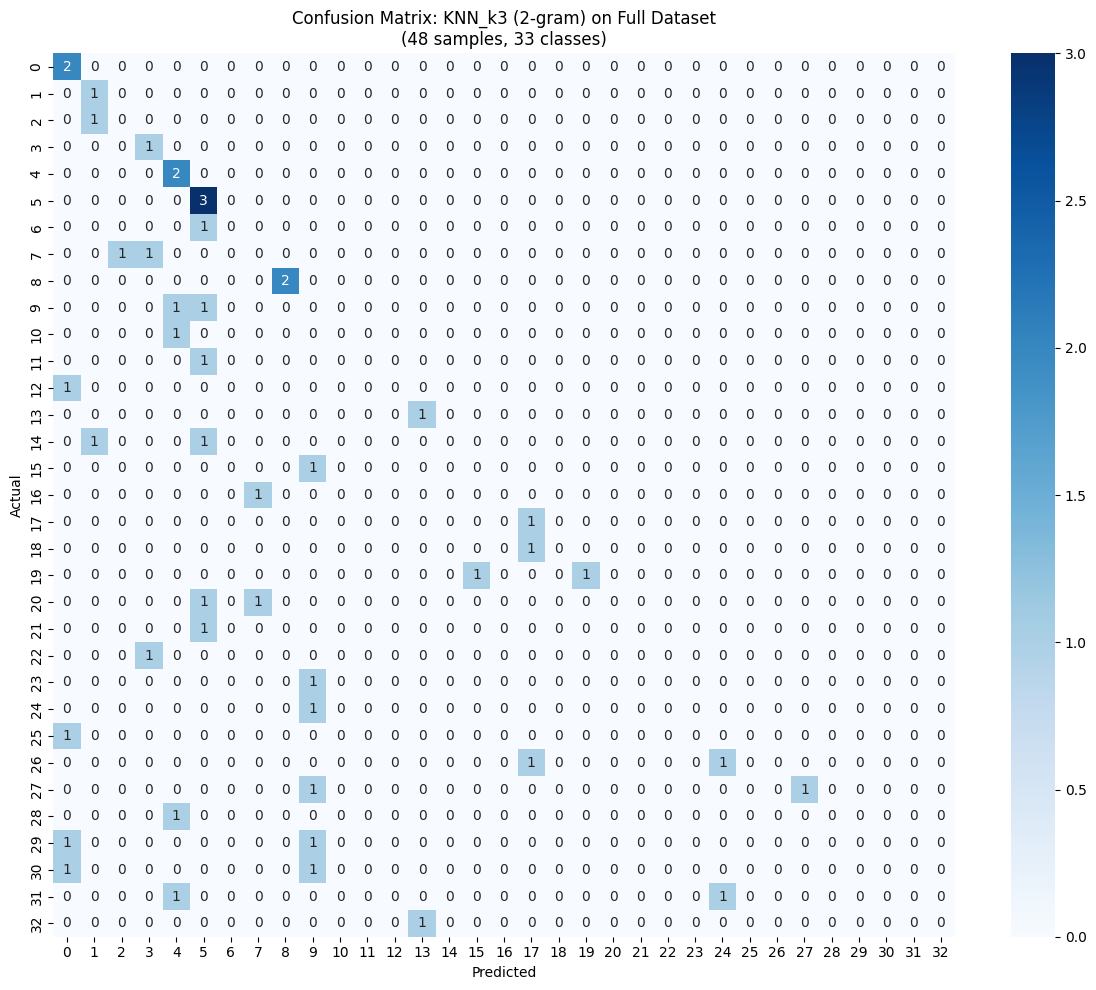


Files saved:
- 'comprehensive_metrics_results.csv' (all metrics)
- 'comprehensive_metrics_comparison.png' (4 metrics plots)
- 'best_model_confusion_matrix.png' (representative CM)


In [18]:
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneOut, cross_validate
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed opcode data
print("Loading preprocessed data...")
with open('ml_data/preprocessing_data.pkl', 'rb') as f:
    X1, X2, y, _, _ = pickle.load(f)

print(f"Dataset: {X1.shape[0]} samples, {len(np.unique(y))} unique classes")
loo = LeaveOneOut()

# Updated classifiers
models = {
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN_k3': KNeighborsClassifier(n_neighbors=3),
    'KNN_k5': KNeighborsClassifier(n_neighbors=5),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}

# Fixed scoring - use lowercase consistent keys
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# Run LOO-CV for all models with comprehensive metrics
results = {}
print("\nRunning Leave-One-Out Cross-Validation with comprehensive metrics...")
for name, model in models.items():
    print(f"\n--- Evaluating {name} ---")
    
    # 1-gram evaluation
    cv_results1 = cross_validate(model, X1, y, cv=loo, scoring=scoring)
    acc1 = cv_results1['test_accuracy'].mean()
    prec1 = cv_results1['test_precision_macro'].mean()
    rec1 = cv_results1['test_recall_macro'].mean()
    f11 = cv_results1['test_f1_macro'].mean()
    
    # 2-gram evaluation  
    cv_results2 = cross_validate(model, X2, y, cv=loo, scoring=scoring)
    acc2 = cv_results2['test_accuracy'].mean()
    prec2 = cv_results2['test_precision_macro'].mean()
    rec2 = cv_results2['test_recall_macro'].mean()
    f12 = cv_results2['test_f1_macro'].mean()
    
    results[name] = {
        '1gram': {'accuracy': acc1, 'precision': prec1, 'recall': rec1, 'f1': f11},
        '2gram': {'accuracy': acc2, 'precision': prec2, 'recall': rec2, 'f1': f12}
    }
    
    print(f"{name}:")
    print(f"  1-gram - Acc: {acc1:.3f}, Prec: {prec1:.3f}, Rec: {rec1:.3f}, F1: {f11:.3f}")
    print(f"  2-gram - Acc: {acc2:.3f}, Prec: {prec2:.3f}, Rec: {rec2:.3f}, F1: {f12:.3f}")

# Detailed results DataFrame
detailed_results = []
for name, metrics in results.items():
    detailed_results.append({
        'Classifier': name, 'Ngram': '1-gram',
        'Accuracy': metrics['1gram']['accuracy'],
        'Precision': metrics['1gram']['precision'],
        'Recall': metrics['1gram']['recall'],
        'F1-Score': metrics['1gram']['f1']
    })
    detailed_results.append({
        'Classifier': name, 'Ngram': '2-gram',
        'Accuracy': metrics['2gram']['accuracy'],
        'Precision': metrics['2gram']['precision'],
        'Recall': metrics['2gram']['recall'],
        'F1-Score': metrics['2gram']['f1']
    })

df_detailed = pd.DataFrame(detailed_results).round(3)
df_detailed.to_csv('results/comprehensive_metrics_results.csv', index=False)
print("\nDetailed metrics saved to 'comprehensive_metrics_results.csv'")

# Summary table (Accuracy only for overview)
summary_df = pd.DataFrame({
    name: [data['1gram']['accuracy'], data['2gram']['accuracy']] 
    for name, data in results.items()
}, index=['1-gram', '2-gram']).round(3)
print("\nAccuracy Summary:")
print(summary_df)

# Visualization 1: All metrics comparison - FIXED
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics_list = ['accuracy', 'precision', 'recall', 'f1']  # lowercase dict keys
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = ['#1f77b4', '#ff7f0e']

for i, (metric_key, metric_name) in enumerate(zip(metrics_list, metric_names)):
    ax = axes[i//2, i%2]
    x = np.arange(len(models))
    width = 0.35
    
    # 1-gram bars
    vals1 = [results[name]['1gram'][metric_key] for name in models.keys()]
    ax.bar(x - width/2, vals1, width, label='1-gram', color=colors[0], 
           edgecolor='black', alpha=0.8)
    
    # 2-gram bars  
    vals2 = [results[name]['2gram'][metric_key] for name in models.keys()]
    ax.bar(x + width/2, vals2, width, label='2-gram', color=colors[1], 
           edgecolor='black', alpha=0.8)
    
    # Labels on bars - FIXED indexing
    for j, name in enumerate(models.keys()):
        ax.text(j - width/2, vals1[j] + 0.005, f'{vals1[j]:.3f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
        ax.text(j + width/2, vals2[j] + 0.005, f'{vals2[j]:.3f}', 
                ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    ax.set_title(f'{metric_name} Comparison (LOO-CV)')
    ax.set_xlabel('Classifier')
    ax.set_ylabel(metric_name)
    ax.set_xticks(x)
    ax.set_xticklabels(list(models.keys()), rotation=15)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Comprehensive Opcode Classification Metrics: 48 Samples, 33 APT Families (LOO-CV)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('results/comprehensive_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion Matrix for Best Model
print("\nGenerating confusion matrix for best model...")
best_model_name = max(results.keys(), key=lambda k: results[k]['2gram']['accuracy'])
print(f"Best model: {best_model_name} (2-gram)")

# Train best model on full data for representative confusion matrix
best_model = models[best_model_name]
best_model.fit(X2, y)
y_pred_full = best_model.predict(X2)

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y, y_pred_full)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=True, yticklabels=True)
plt.title(f'Confusion Matrix: {best_model_name} (2-gram) on Full Dataset\n({len(y)} samples, {len(np.unique(y))} classes)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('results/best_model_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nFiles saved:")
print("- 'comprehensive_metrics_results.csv' (all metrics)")
print("- 'comprehensive_metrics_comparison.png' (4 metrics plots)")
print("- 'best_model_confusion_matrix.png' (representative CM)")

